# 协同过滤评估可视化

本 notebook 用于展示基于物品的协同过滤评估流程，包括数据加载、训练/测试划分、单用户推荐、整体指标评估、`top_k` 敏感性分析和可视化。

主模型位于 `src/cf_recommender.py`，评估逻辑位于 `src/evaluation.py`。

## 1. 环境与数据加载

先导入项目模块，并加载评分矩阵。这里会顺手检查 `scikit-learn` 版本，确保当前环境可正常使用。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from IPython.display import display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cf_recommender import (
    attach_movie_titles,
    compute_item_similarity,
    load_movie_title_map,
    predict_ratings_item_based,
    recommend_items_item_based,
)
from src.evaluation import (
    evaluate_algorithm,
    evaluate_item_cf,
    load_filtered_matrix,
    sensitivity_analysis,
    train_test_split_matrix,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

print('project_root =', project_root)
print('scikit-learn =', sklearn.__version__)


project_root = D:\Movie-Recommender-System
scikit-learn = 1.6.1


In [2]:
matrix = load_filtered_matrix()
n_users, n_items = matrix.shape
n_ratings = int(matrix.notna().sum().sum())
sparsity = 1 - n_ratings / (n_users * n_items)

print('matrix shape:', matrix.shape)
print('ratings:', n_ratings)
print('sparsity:', round(sparsity, 4))
display(matrix.head())


matrix shape: (475, 1617)
ratings: 70454
sparsity: 0.9083


,1,2,3,5,6,7,10,11,12,14,...,138036,139385,142488,148626,152081,158238,164179,166528,168252,176371
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. 训练集 / 测试集划分

这里按用户随机抽样测试项，保证训练集和测试集仍保持矩阵结构，便于后续 CF 计算。

In [3]:
train_matrix, test_matrix = train_test_split_matrix(
    matrix,
    test_size=0.2,
    random_state=42,
)

print('train shape:', train_matrix.shape)
print('test shape:', test_matrix.shape)
print('train ratings:', int(train_matrix.notna().sum().sum()))
print('test ratings:', int(test_matrix.notna().sum().sum()))


train shape: (475, 1617)
test shape: (475, 1617)
train ratings: 56361
test ratings: 14093


## 3. 物品相似度与单用户推荐

先计算物品相似度矩阵，再挑选一个样例用户展示 Top-N 推荐结果。如果能读取电影标题映射，则同时展示 `movieId` 与电影名称。

In [4]:
item_sim = compute_item_similarity(train_matrix)
sample_user = train_matrix.index[0]
top_k_neighbors = 20
top_n = 10

preds = predict_ratings_item_based(train_matrix, item_sim, sample_user, top_k=top_k_neighbors)
recs = recommend_items_item_based(train_matrix, sample_user, n=top_n, top_k=top_k_neighbors)

print('sample_user:', sample_user)
display(preds.head(top_n).to_frame('pred_rating'))

try:
    movie_titles = load_movie_title_map(project_root)
    display(attach_movie_titles(recs, movie_titles))
except Exception as exc:
    print('movie title map unavailable:', exc)
    display(pd.DataFrame(recs, columns=['movieId', 'pred_rating']))


sample_user: 1


,pred_rating
176371,5.0
2,5.0
5,5.0
7,5.0
10,5.0
11,5.0
134130,5.0
128360,5.0
122926,5.0
122922,5.0


,movieId,title,pred_rating
0,176371,Blade Runner 2049 (2017),5.0
1,2,Jumanji (1995),5.0
2,5,Father of the Bride Part II (1995),5.0
3,7,Sabrina (1995),5.0
4,10,GoldenEye (1995),5.0
5,11,"American President, The (1995)",5.0
6,134130,The Martian (2015),5.0
7,128360,The Hateful Eight (2015),5.0
8,122926,Untitled Spider-Man Reboot (2017),5.0
9,122922,Doctor Strange (2016),5.0


## 4. 整体评估

为了让 notebook 运行更稳定，这里默认只取前 `EVAL_USER_COUNT` 个有测试评分的用户做演示。需要全量评估时，把它设成 `None`。

In [5]:
EVAL_USER_COUNT = 20
eval_user_ids = [uid for uid in test_matrix.index if test_matrix.loc[uid].notna().any()]
if EVAL_USER_COUNT is not None:
    eval_user_ids = eval_user_ids[:EVAL_USER_COUNT]

evaluation_result = evaluate_algorithm(
    train_matrix=train_matrix,
    test_matrix=test_matrix,
    algorithm='item',
    top_k_neighbors=20,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
)

display(evaluation_result)
display(evaluation_result.attrs['per_user_results'].head())


,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,RMSE,MAE,Precision@K,Recall@K
0,item,20,10,20,593,1.677054,1.378847,0.025,0.018818


,userId,RMSE,MAE,Precision@K,Recall@K
0,1,0.847319,0.461538,0.0,0.000000
1,4,2.265686,1.600000,0.0,0.000000
2,5,1.658312,1.500000,0.0,0.000000
3,6,1.515684,1.216216,0.2,0.086957
4,7,2.038099,1.615385,0.0,0.000000


## 5. `top_k` 敏感性分析

对不同邻居数进行重复评估，观察 RMSE、MAE、Precision@K 和 Recall@K 的变化趋势。

In [6]:
sensitivity = sensitivity_analysis(
    matrix,
    top_k_values=(5, 10, 20, 40),
    test_size=0.2,
    random_state=42,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
)

display(sensitivity)


,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,RMSE,MAE,Precision@K,Recall@K
0,item,5,10,20,593,1.668709,1.369422,0.025,0.018818
1,item,10,10,20,593,1.673783,1.374892,0.025,0.018818
2,item,20,10,20,593,1.677054,1.378847,0.025,0.018818
3,item,40,10,20,593,1.571002,1.293420,0.020,0.008818


## 6. 评估结果可视化

下面把敏感性分析结果画成折线图，便于比较不同 `top_k` 设置下的指标变化。

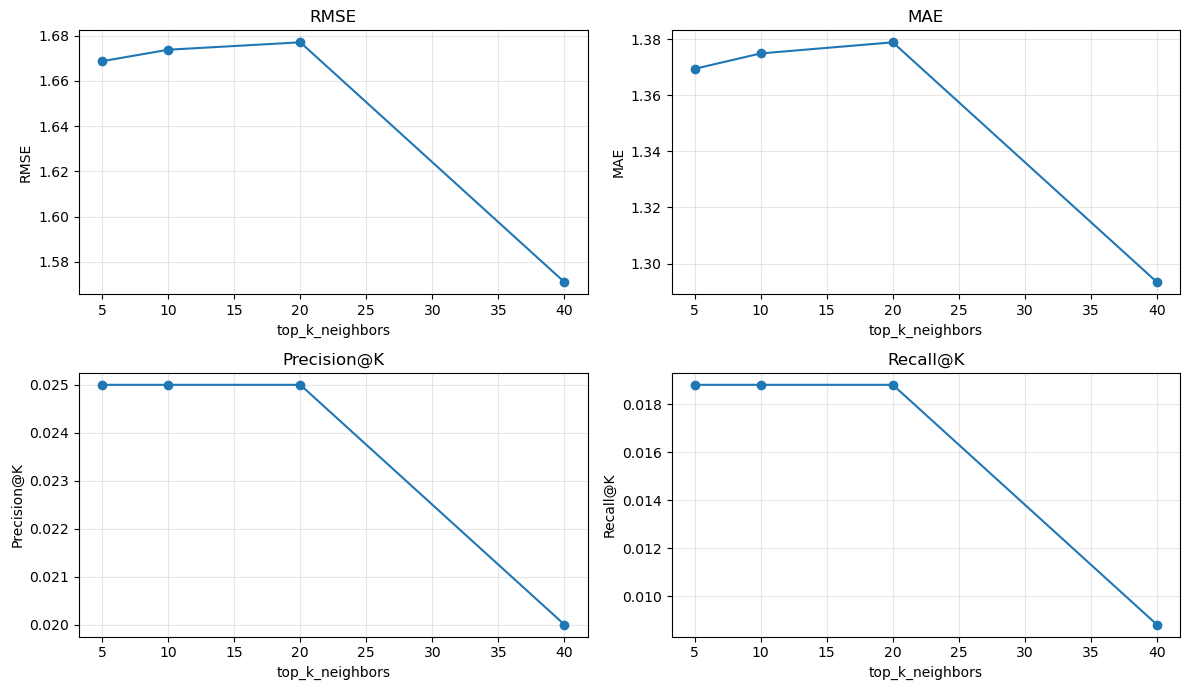

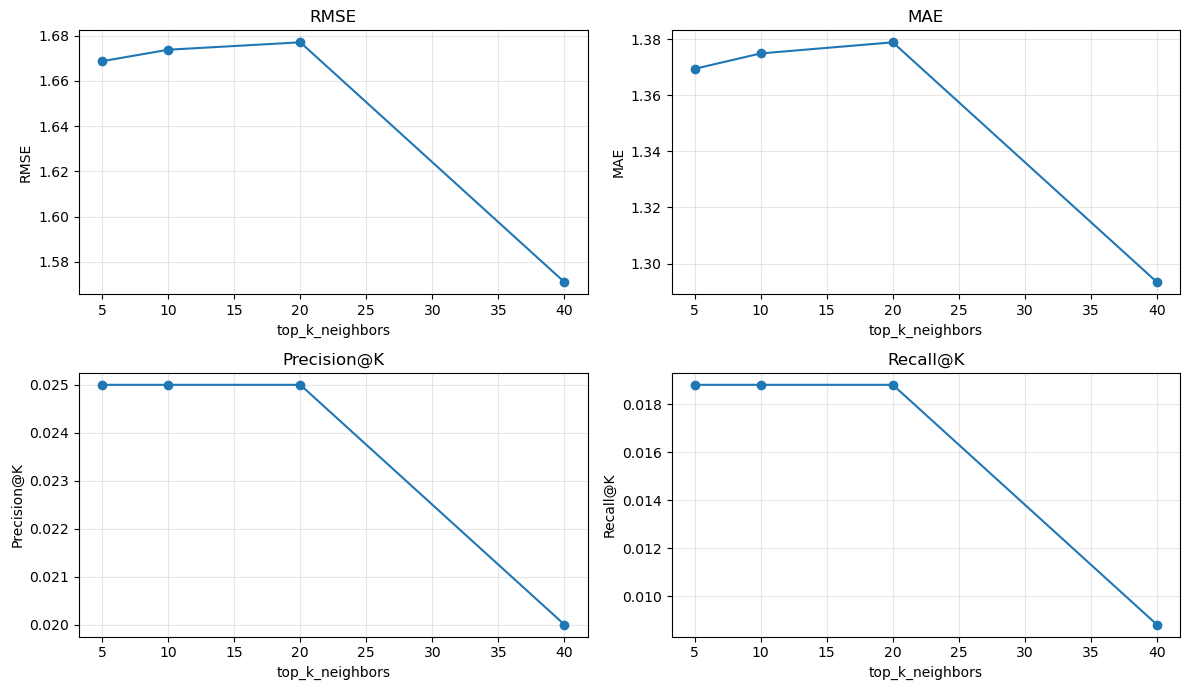

In [7]:
metrics = ['RMSE', 'MAE', 'Precision@K', 'Recall@K']
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for ax, metric in zip(axes, metrics):
    ax.plot(sensitivity['top_k_neighbors'], sensitivity[metric], marker='o')
    ax.set_xlabel('top_k_neighbors')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(alpha=0.3)

fig.tight_layout()
fig


## 7. 结论记录

- 主模型为基于物品的协同过滤。
- 评估逻辑统一由 `src/evaluation.py` 提供。
- Notebook 只负责展示和可视化，不再混入算法实现。